# PSTAT 100 Data Science Concepts and Analysis

## Assignment 3

**Author:**
**Date:**

---

#### Submission Instructions

This assignment will be **due for submission on Wednesday May 27th at 11:59PM**.  Please ensure you submit a `.pdf` file to Canvas by the posted time, no other file types will be accepted.  Please see the course website for some information regarding exporting Jupyter notebooks to pdf, and if you are having exporting problems discuss them with a member of the teaching staff in their office hours.

___

#### Collaboration

You are encouraged to work on your assignments independently.  Please only collaborate with others should you require assistance with more challenging problems. Should you need to collaborate with others, please note their names here:

> **Collaborators:** None
___

#### Agent Usage

Additionally, you are permitted to use resources such as ChatGPT and Claude to help you with your homework assignments and to enhance your learning experience. Please make a note of any agents you have used in this submission here:

> **Agents:** Claude

**WARNING:** Please ensure you check and understand the outputs these agents produce.  Should your solution show evidence of abuse of AI usage (i.e. use external data not detailed in this assignment, use methods not covered in class) your solution will receive a score of 0.

---

## 1. Introduction

In this report we will be performing a statistical analysis to investigate the effect of economic, demographic and health factors on human life expectancy across various countries.  Our study will be utilizing the [Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who?resource=download) data, made available on Kaggle by Kumar Rajarshi and originally collected from WHO and United Nations website with the help of Deeksha Russell and Duan Wang.

In this project we consider data from year 2000-2015 for 193 countries for further analysis.  This will involve:

- **Data Preparation:**
    - Data Importing
    - Missingness.
    - Data Transformations.
- **Exploratory Data Analysis:**
    - Summary Statistic Tables
    - Univariate Distributions
    - Bivariate Relationships
- **Modelling:**
    - Fit a Simple Linear Regression (SLR) model. 
    - Fit several Multiple Linear Regression (MLR) models.
    - Evaluate model performance.
    - Residual analysis.

In this report we will be making use of the following libraries:

In [1]:
# Libraries
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import probplot

# Figure formatting
sns.set_style("whitegrid")
sns.set_palette("Set2") 

---

## 2. Data Preparation

In this section we will load and prepare the data.  Download the `life_expectancy.csv` file from Canvas.  Print the first 5 rows of this data set as well as the shape of the data using the chunk below:

In [2]:
# Load data
df = pd.read_csv("/Users/cyrusisaacs/PSTAT 100/Data/life_expectancy.csv")
# Print shape
print("Shape: ", df.shape)
# Print column names
print(f"  Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"    {c!r}")
# Print first 5 rows
df.head()

Shape:  (2938, 22)
  Columns (22):
    'Country'
    'Year'
    'Status'
    'Life expectancy '
    'Adult Mortality'
    'infant deaths'
    'Alcohol'
    'percentage expenditure'
    'Hepatitis B'
    'Measles '
    ' BMI '
    'under-five deaths '
    'Polio'
    'Total expenditure'
    'Diphtheria '
    ' HIV/AIDS'
    'GDP'
    'Population'
    ' thinness  1-19 years'
    ' thinness 5-9 years'
    'Income composition of resources'
    'Schooling'


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


We notice that the data column names are inconsistently formatted which will make our life more challenging in future if we do not address it.  To see 

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.1 Column Formatting

Reformat the column names in the following ways:

1. Remove whitespace (spaces before and after) using `strip`.
2. Remove all capitalization.
3. Replace internal spacing with underscores "_".
4. Replace any character that is **not** a lowercase letter, digit or underscore.

**Hint:** For (4) look up what the regex `[^a-z0-9_]` means and how it can be used with `str.replace(...)`.

---

In [3]:
# Your solution here

df.columns = (
    df.columns
    .str.strip()                    
    .str.lower()                   
    .str.replace(' ', '_')          
    .str.replace(r'[^a-z0-9_]', '', regex=True)  
)

---

Use the following chunk to ensure that our column relabelling was successful. You should see 22 column names with only lower case letters, numbers and underscores:

In [4]:
# Print cleaned column names
print(f"  Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"    {c!r}")

  Columns (22):
    'country'
    'year'
    'status'
    'life_expectancy'
    'adult_mortality'
    'infant_deaths'
    'alcohol'
    'percentage_expenditure'
    'hepatitis_b'
    'measles'
    'bmi'
    'underfive_deaths'
    'polio'
    'total_expenditure'
    'diphtheria'
    'hivaids'
    'gdp'
    'population'
    'thinness__119_years'
    'thinness_59_years'
    'income_composition_of_resources'
    'schooling'


Next we inspect the data types used in each column using the chunk below:

In [5]:
# Check data types
df.dtypes

country                                str
year                                 int64
status                                 str
life_expectancy                    float64
adult_mortality                    float64
infant_deaths                        int64
alcohol                            float64
percentage_expenditure             float64
hepatitis_b                        float64
measles                              int64
bmi                                float64
underfive_deaths                     int64
polio                              float64
total_expenditure                  float64
diphtheria                         float64
hivaids                            float64
gdp                                float64
population                         float64
thinness__119_years                float64
thinness_59_years                  float64
income_composition_of_resources    float64
schooling                          float64
dtype: object

All we need to do is convert `status` into a category type which we do as follows:

In [6]:
# Change status to categorical variable
df["status"] = df["status"].astype("category")

Next we proceed to evaluating the missingness of the data.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.2 Missingness Tables

Produce the following tables:

- A standard missingness table showing the counts and percentages of missing data for each column.
- A missingness table showing the percentages of missing data for each column, grouped by status.

We will be using simple imputation (replacement with median) to handle missing values in numerical columns.  Using this table and by reading the data documentation on Kaggle, comment on the validity of this choice.  Consider the following questions:

- Is the data Missing Completely At Random (MCAR)?
- Might there be underlying patterns to the missingness?

---

In [7]:
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percent': (df.isnull().mean() * 100)
})

missing_table = missing_table.sort_values(
    by='Missing Percent',
    ascending=False
)

print("Standard Missingness Table")
print(missing_table)

missing_by_status = (
    df.groupby('status')
      .apply(lambda x: x.isnull().mean() * 100)
      .T
)

print("\nMissingness Percentage by Status")
print(missing_by_status)

Standard Missingness Table
                                 Missing Count  Missing Percent
population                                 652        22.191967
hepatitis_b                                553        18.822328
gdp                                        448        15.248468
total_expenditure                          226         7.692308
alcohol                                    194         6.603131
income_composition_of_resources            167         5.684139
schooling                                  163         5.547992
thinness_59_years                           34         1.157250
thinness__119_years                         34         1.157250
bmi                                         34         1.157250
polio                                       19         0.646698
diphtheria                                  19         0.646698
life_expectancy                             10         0.340368
adult_mortality                             10         0.340368
hivaids      

---

Is the data MCAR?
No. The data is unlikely to be Missing Completely At Random (MCAR), since missingness probably depends on factors such as country development level, healthcare infrastructure, and reporting quality.

Might there be underlying patterns to the missingness?
Yes. Developing countries may have more missing data for variables like GDP, healthcare spending, and vaccinations, suggesting systematic patterns in the missingness.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q2.3 Missing Data Imputation

First, isolate the 20 columns that are numeric and store their names in `numeric_cols`.  Then, write a `for` loop that iterates over these numeric columns and performs the following:

1. Replaces any missing values with the median of that column for that country.
2. Replaces any remaining missing values with the median for that entire column.

Check that your imputation has successfully removed all missing values by using the following:

```
print(f"\n  After imputation — remaining nulls: {df.isnull().sum().sum()}")
```

---

In [8]:
numeric_cols = df.select_dtypes(include='number').columns


for col in numeric_cols:

    
    df[col] = df.groupby('country')[col].transform(
        lambda x: x.fillna(x.median())
    )

    df[col] = df[col].fillna(df[col].median())


print(f"\nAfter imputation — remaining nulls: {df.isnull().sum().sum()}")


After imputation — remaining nulls: 0


---

We conclude our preparation by noting that several covariates are very heavily right skewed.  We can see this by producing a multiplot of the histograms of all numerical variables:

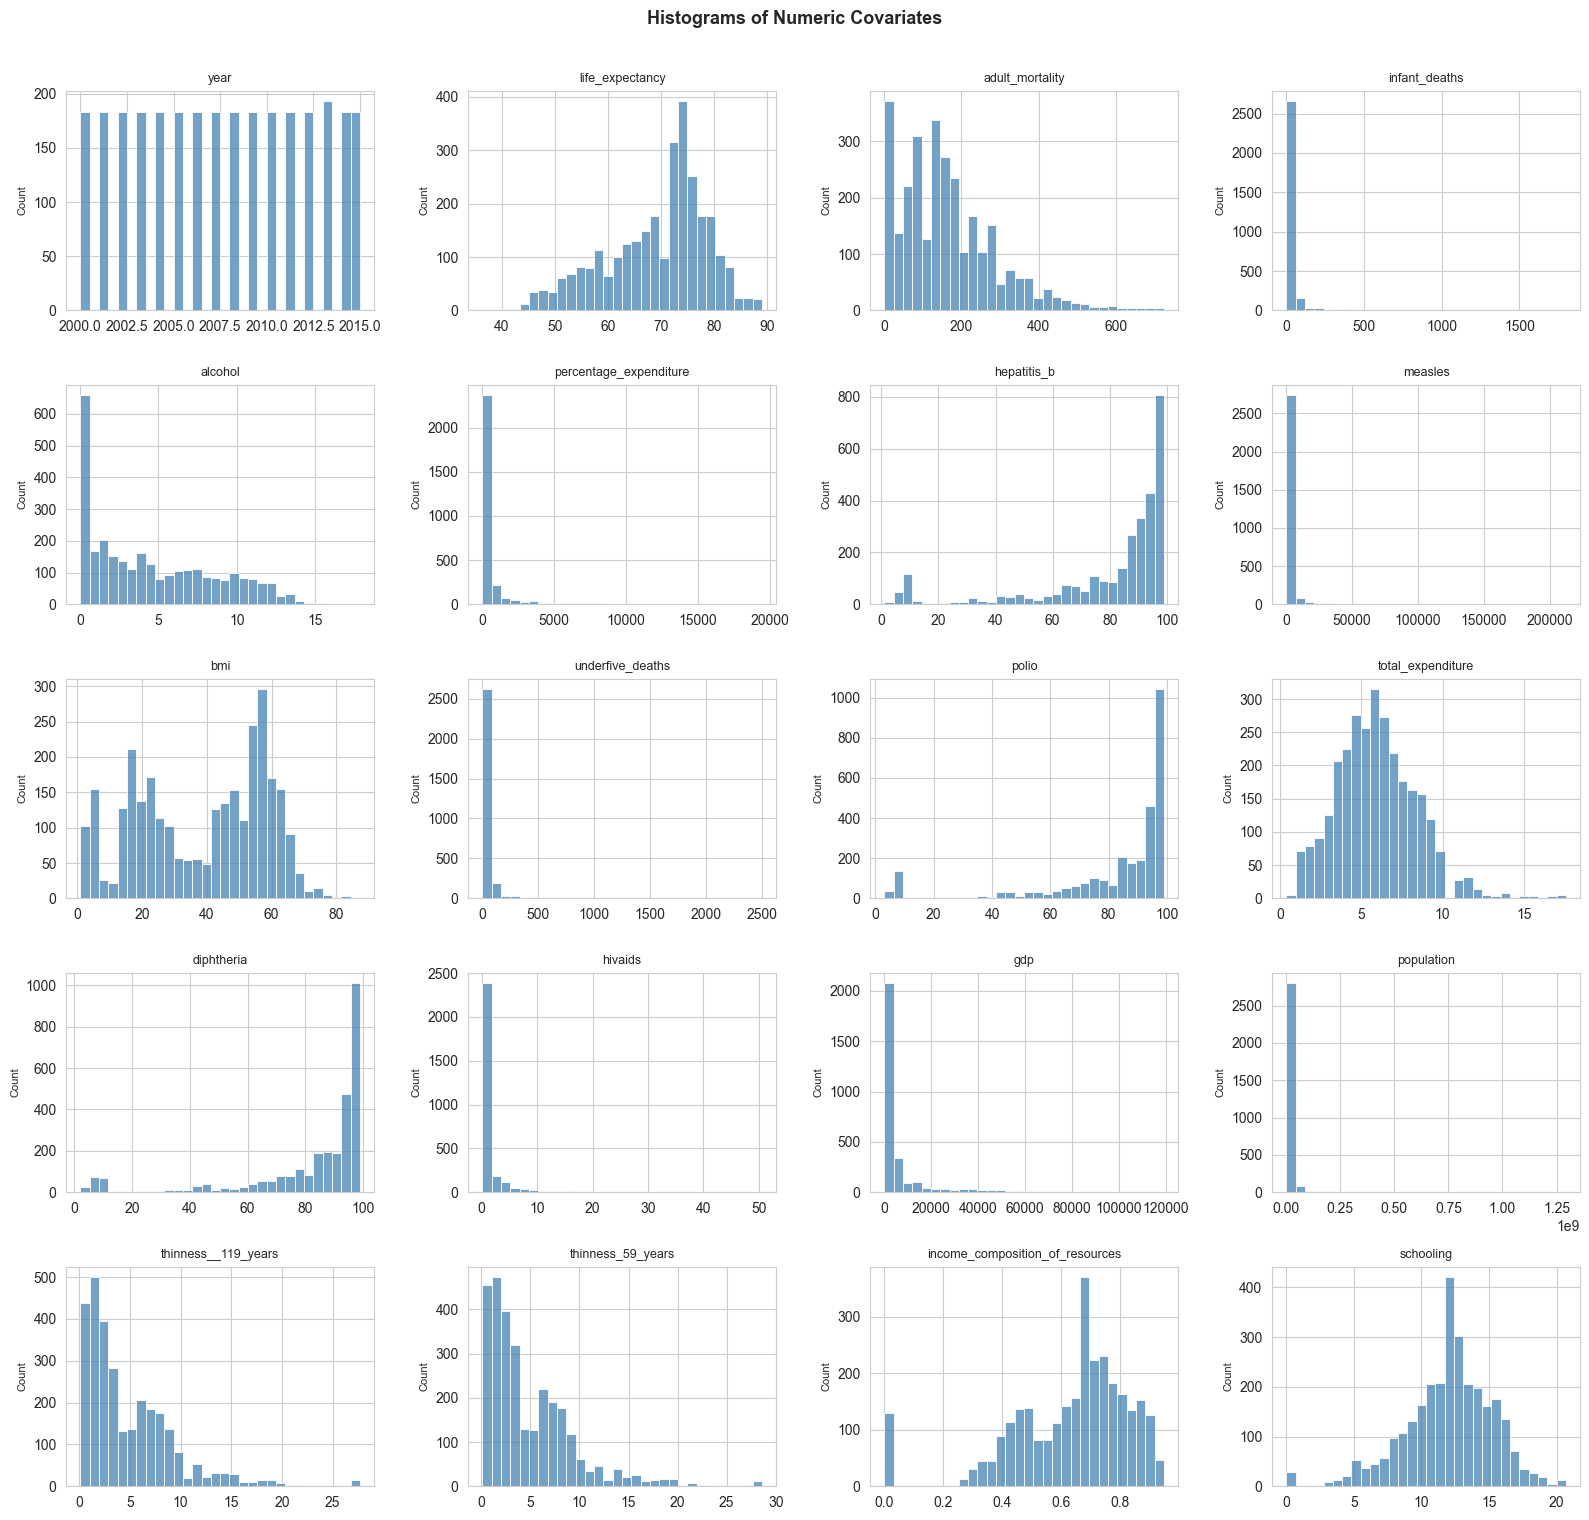

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], bins=30, color="steelblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize=8)

# Hide any unused axes
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histograms of Numeric Covariates", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

We therefore use the following chunk to take the log of these variables.

In [10]:
skewed = ['infant_deaths', 'percentage_expenditure', 'measles', 'underfive_deaths', 'hivaids', 'gdp', 'population']

for col in skewed:
    if col in df.columns:
        df[col] = np.log1p(df[col].clip(lower=0))

## 3. Exploratory Data Analysis

### 3.1 Summary Statistics

We proceed to our data exploration and start by producing tables of summary statistics.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.1 Summary Statistics

Produce a table of the key summary statistics (mean, standard deviation, minimum, LQ, median, UQ, max, range, skew and kurtosis) for all numerical covariates.  Provide a few comments on the results including observations about skewed covariates, potential outliers or other points of note.

---

In [11]:

summary_table = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Std Dev': df[numeric_cols].std(),
    'Min': df[numeric_cols].min(),
    'LQ': df[numeric_cols].quantile(0.25),
    'Median': df[numeric_cols].median(),
    'UQ': df[numeric_cols].quantile(0.75),
    'Max': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Skew': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
})

summary_table = summary_table.round(3)

print(summary_table)

                                     Mean  Std Dev       Min        LQ  \
year                             2007.519    4.614  2000.000  2004.000   
life_expectancy                    69.235    9.509    36.300    63.200   
adult_mortality                   164.726  124.086     1.000    74.000   
infant_deaths                       1.769    1.663     0.000     0.000   
alcohol                             4.605    4.034     0.010     0.923   
percentage_expenditure              3.986    2.730     0.000     1.738   
hepatitis_b                        80.100   24.554     1.000    75.000   
measles                             3.357    3.259     0.000     0.000   
bmi                                38.381   19.935     1.000    19.400   
underfive_deaths                    1.940    1.782     0.000     0.000   
polio                              82.417   23.478     3.000    78.000   
total_expenditure                   5.917    2.469     0.370     4.260   
diphtheria                         82.

Several variables such as gdp, population, measles, and percentage_expenditure were strongly right-skewed before transformation. The log transformation reduced this skewness substantially.
Some variables may still show moderate skewness and high kurtosis, indicating the presence of extreme values or outliers.
Variables with high kurtosis suggest heavier tails than a normal distribution, meaning a small number of countries have unusually extreme values.


---

### 3.2 Univariate Analysis

First, lets consider our categorical covariate `status`. 

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.2 Countplot of `status`

Produce a countplot of the covariate `status` to visualize the proportion of developing countries against developed countries.  Comment on your resulting plot.

---

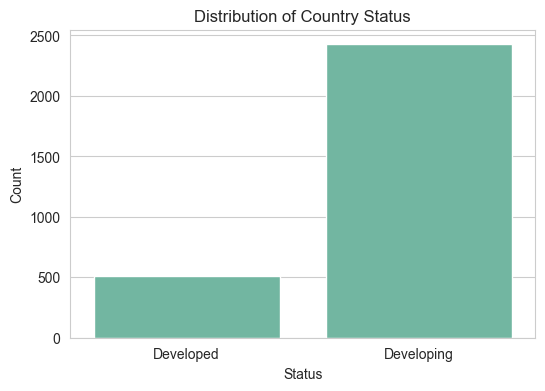

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='status'
)

plt.title('Distribution of Country Status')
plt.xlabel('Status')
plt.ylabel('Count')

plt.show()

The dataset is heavily dominated by developing countries, with substantially fewer developed countries represented.
This indicates a class imbalance in the status variable.
The imbalance reflects the real world distribution of countries included in the WHO dataset, where more observations are available from developing nations across multiple years.
This imbalance should be considered in later analyses, since relationships in the data may be influenced more strongly by patterns within developing countries.

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.3 Histogram Multiplot

Produce a multiplot with 5 rows and 4 columns showing estimates for the distributions for the 20 numerical covariates.  Discuss your findings and the distributions of our transformed covariates.

---

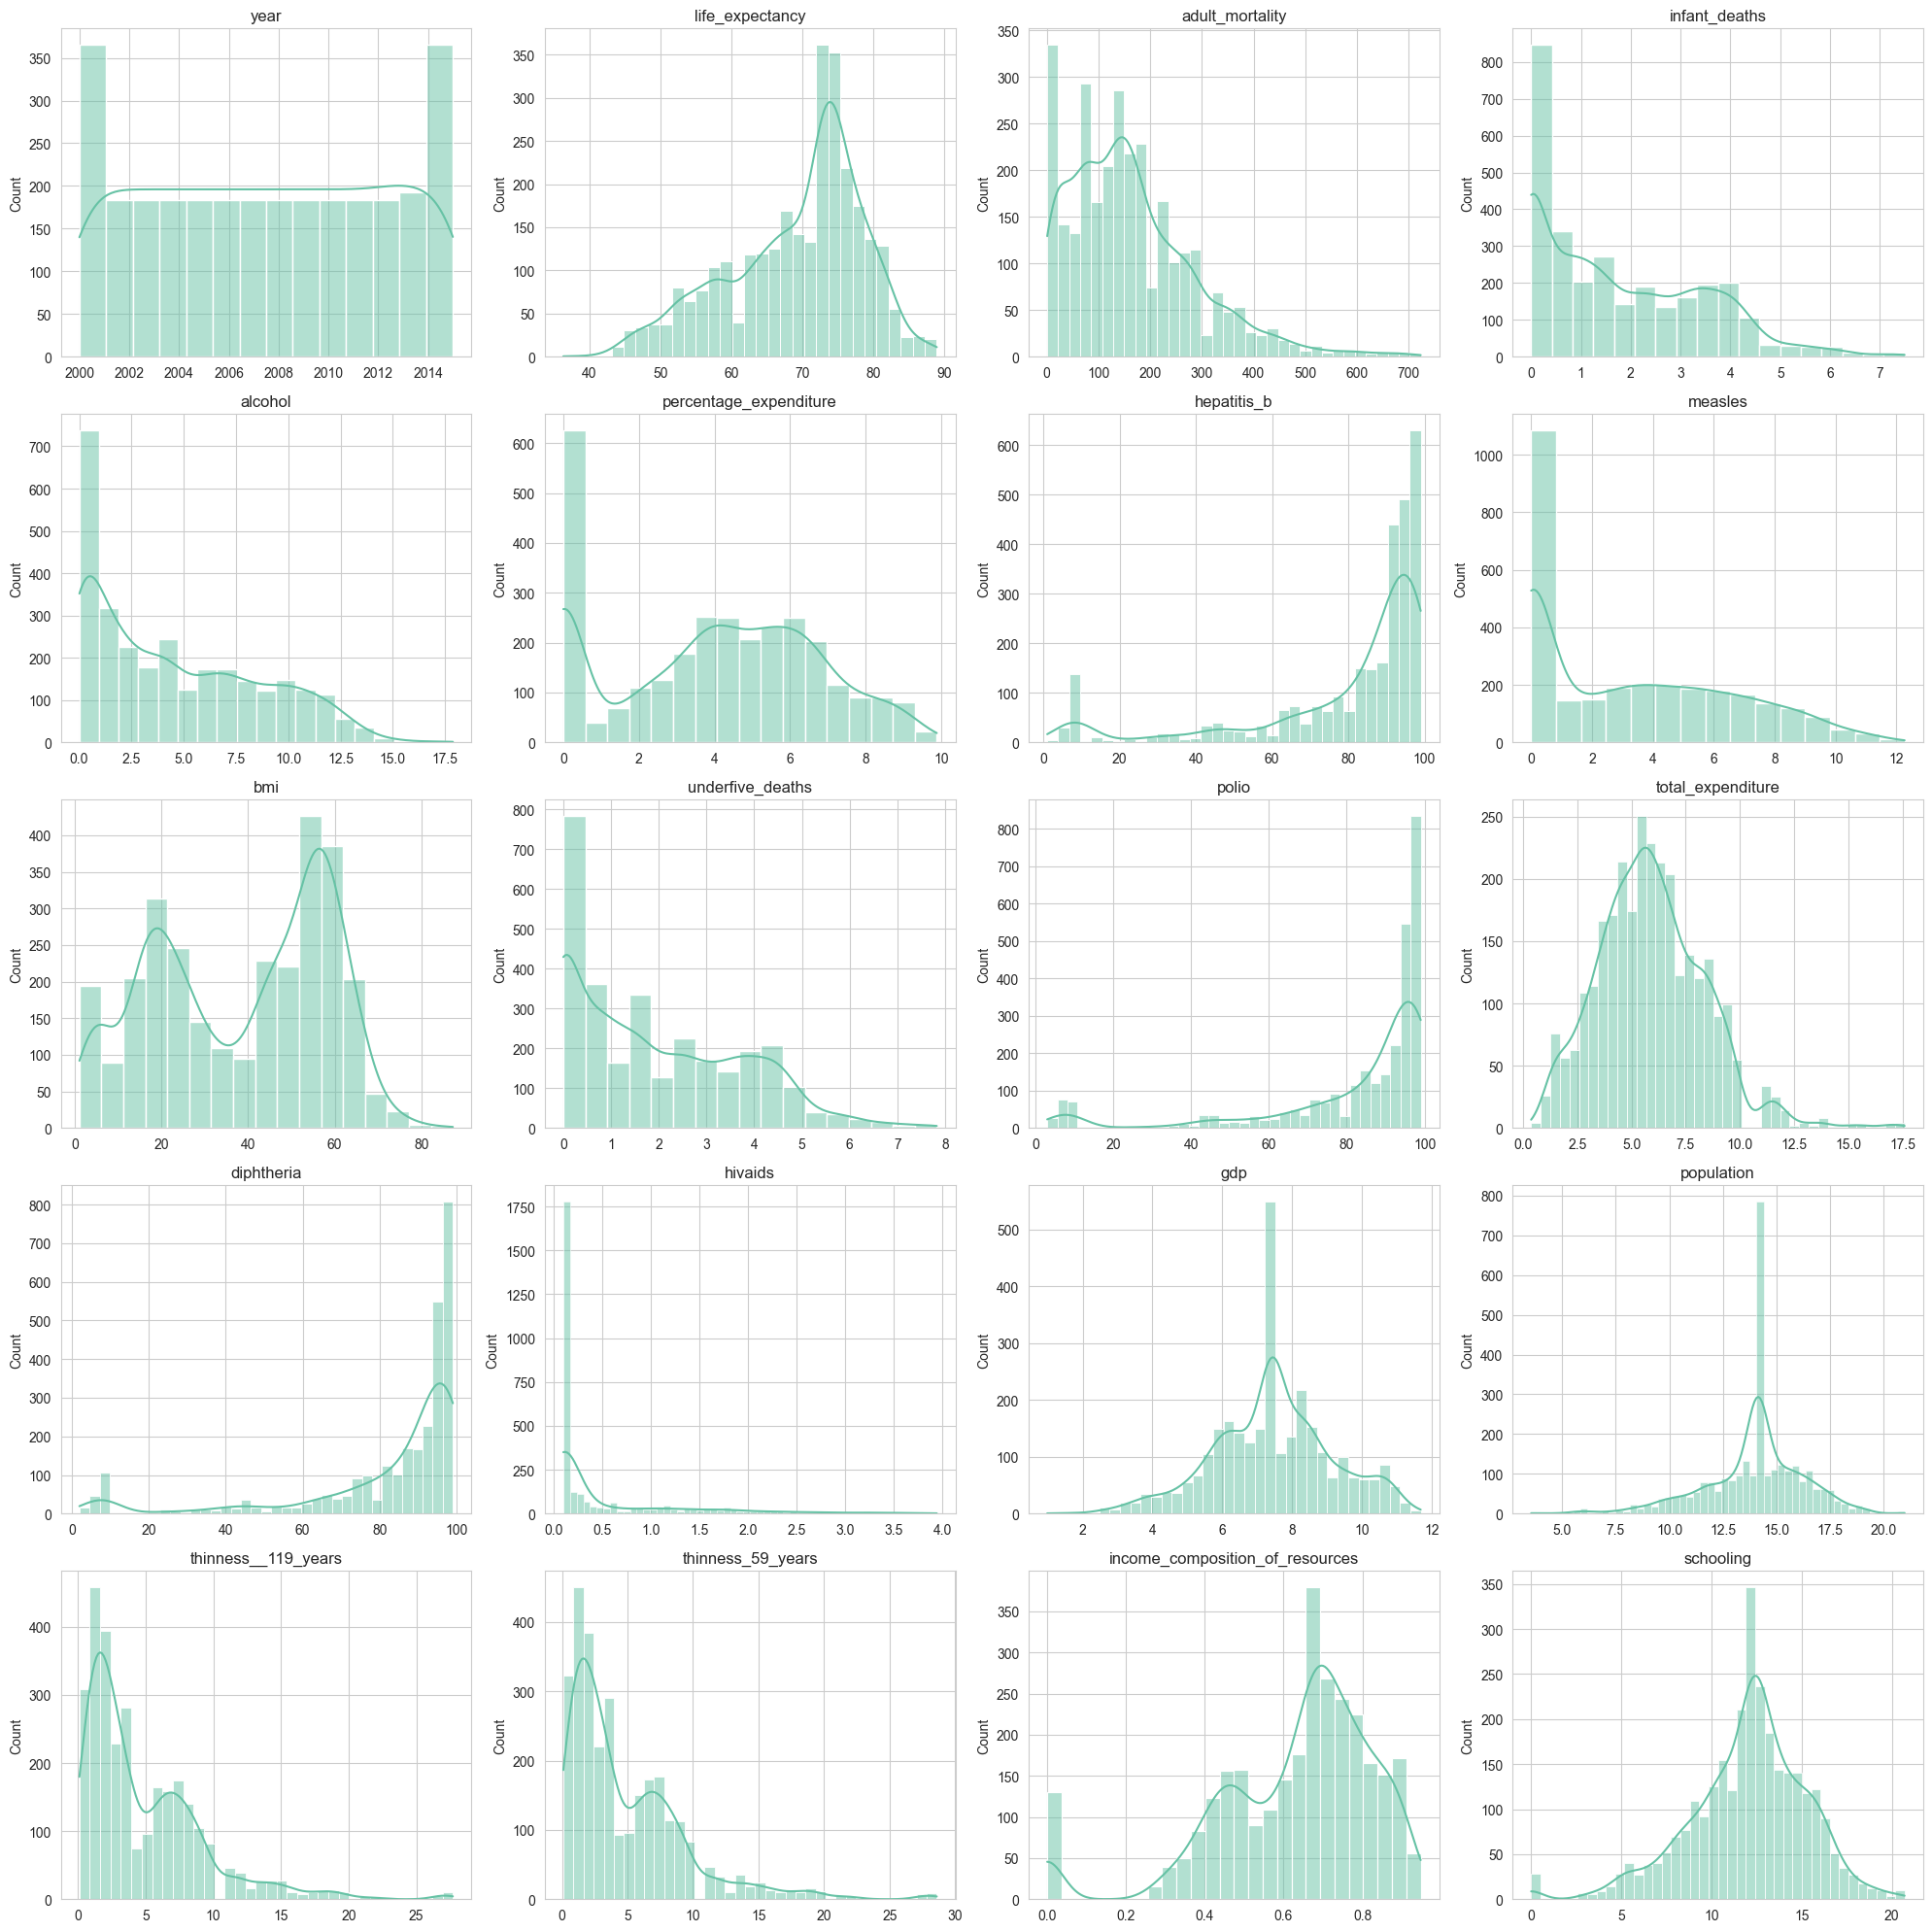

In [13]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

Many of the numerical covariates originally showed strong right skewness, particularly:gdp populationpercentage_expenditure measles underfive_deaths infant_deaths
After applying the log transformation, these variables appear substantially more symmetric and less extreme.
The transformed distributions still show some skewness, but the long right tails have been reduced considerably.
Several variables such as vaccination rates remain concentrated near high values, producing left-skewed distributions.
Variables related to mortality and disease burden still display wider spread and occasional extreme observations, reflecting large differences between countries.
Some distributions appear approximately bell-shaped after transformation, making them more suitable for statistical modelling techniques that assume moderate normality.


---

### 3.3 Bivariate Analysis

We begin our bivariate analysis by looking at the relationship between our response and the categorical variable `status`.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.4 Violin and Grouped Histogram Plot

Produce a multiplot containing the following:

1. A violin plot of `life_expectancy` against `status`; and
2. A histogram of `life_expectancy` grouped by `status`.

Comment on whether you see evidence of a significant difference in the distribution of `life_expectancy` between developed and developing countries.

---

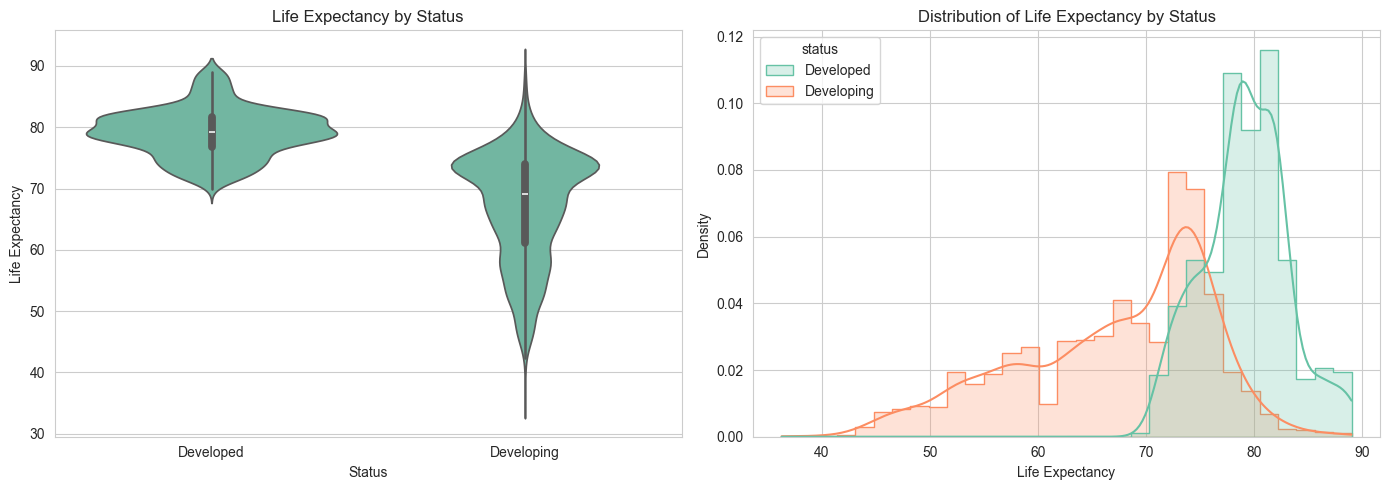

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df,
    x='status',
    y='life_expectancy',
    ax=axes[0]
)

axes[0].set_title('Life Expectancy by Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Life Expectancy')

sns.histplot(
    data=df,
    x='life_expectancy',
    hue='status',
    kde=True,
    element='step',
    stat='density',
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title('Distribution of Life Expectancy by Status')
axes[1].set_xlabel('Life Expectancy')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

Developed countries generally have substantially higher life expectancy than developing countries.
The violin plot shows that developed countries have distributions concentrated at higher life expectancy values with less variability.
Developing countries show a wider spread and lower median life expectancy, indicating greater variation in health outcomes.
The grouped histogram also shows a clear shift:
developed countries are concentrated toward higher life expectancy values,
while developing countries are more spread out and include many lower values.
Overall, the plots provide strong visual evidence of a significant difference in life expectancy distributions between developed and developing countries.

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.5 Correlation Heat Map

Produce a correlation heat map of the numerical variables in the dataset.  Write some code to return the covariates with the strongest correlations.  Comment on the strongest positive and negative correlations you observe.  

---

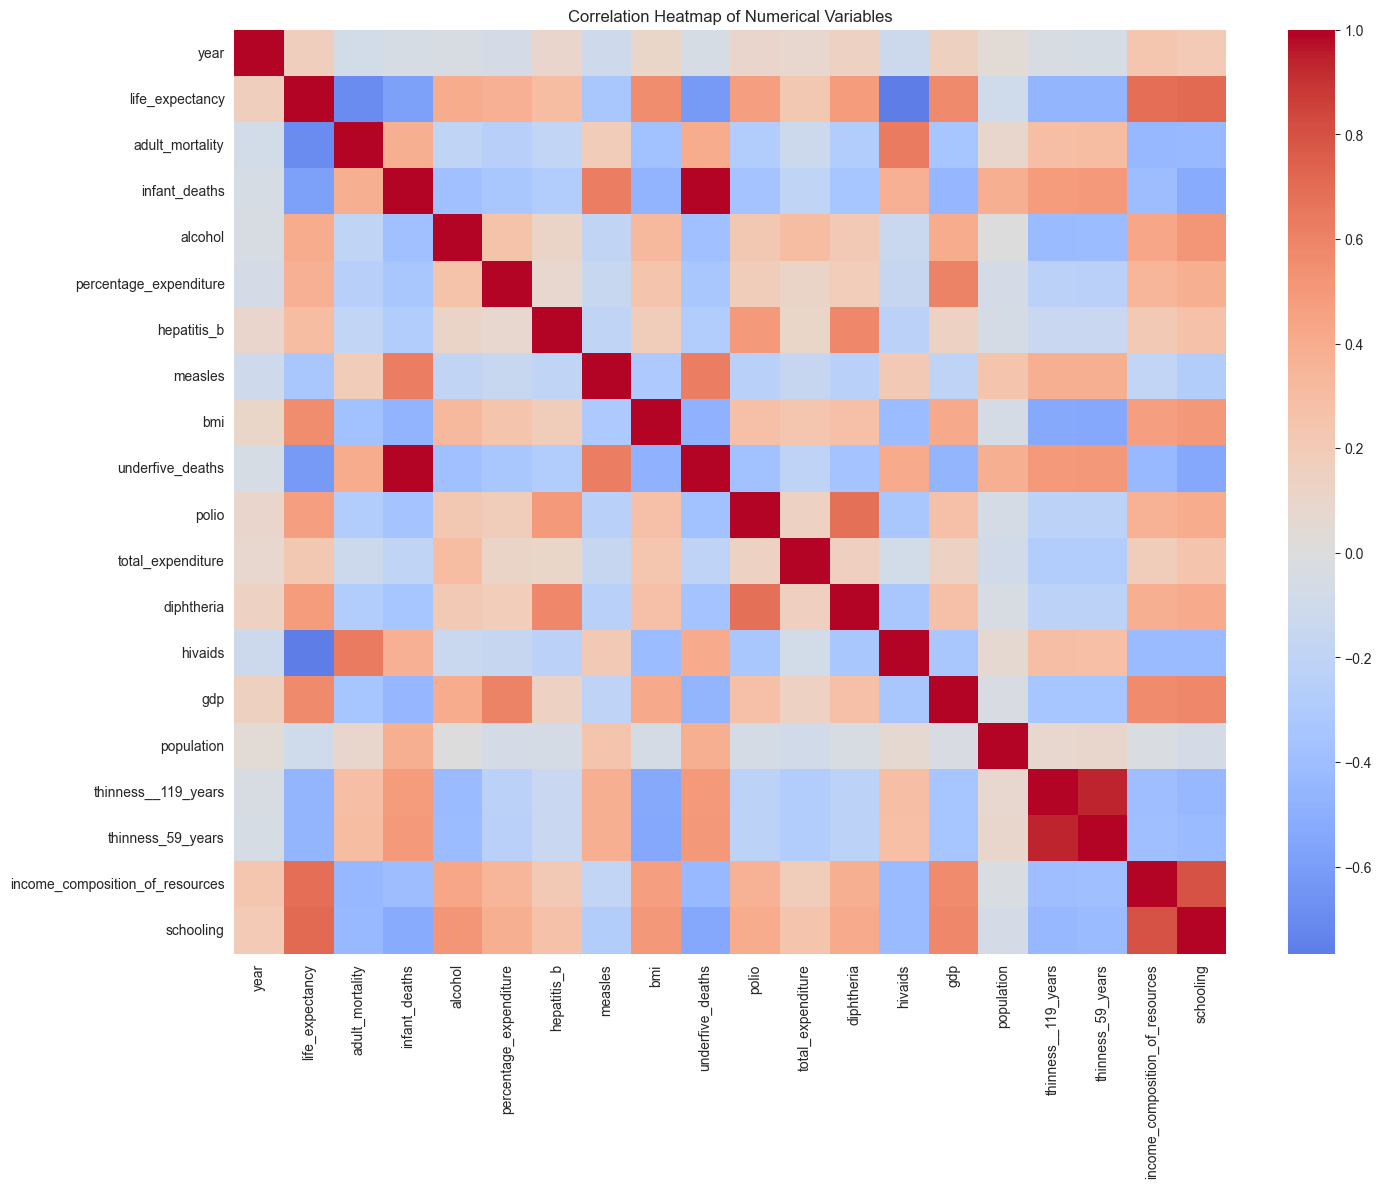

Strongest Negative Correlations
life_expectancy   hivaids               -0.766335
                  adult_mortality       -0.696390
                  underfive_deaths      -0.621177
                  infant_deaths         -0.592058
underfive_deaths  schooling             -0.541438
bmi               thinness_59_years     -0.539365
                  thinness__119_years   -0.532487
infant_deaths     schooling             -0.521825
bmi               underfive_deaths      -0.489748
infant_deaths     bmi                   -0.473661
dtype: float64

Strongest Positive Correlations
percentage_expenditure           gdp                                0.602730
infant_deaths                    measles                            0.623712
measles                          underfive_deaths                   0.623848
adult_mortality                  hivaids                            0.635194
polio                            diphtheria                         0.676887
life_expectancy                  in

In [15]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0)
    != corr_pairs.index.get_level_values(1)
]

corr_pairs = corr_pairs.drop_duplicates()

sorted_corr = corr_pairs.sort_values()

print("Strongest Negative Correlations")
print(sorted_corr.head(10))

print("\nStrongest Positive Correlations")
print(sorted_corr.tail(10))

Strong positive correlations are observed between:
life_expectancy and schooling
life_expectancy and income_composition_of_resources
vaccination-related variables such as polio and diphtheria
These relationships suggest that higher education, stronger economic development, and better healthcare systems are associated with longer life expectancy.
Strong negative correlations are commonly observed between:
life_expectancy and adult_mortality
life_expectancy and hivaids
These negative relationships indicate that higher mortality rates and higher HIV/AIDS prevalence are associated with lower life expectancy.
Some predictors are also highly correlated with one another, which may indicate multicollinearity. For example:
thinness_1_19_years and thinness_5_9_years
income_composition_of_resources and schooling
The heatmap highlights clear clusters of related health, economic, and vaccination variables.

---

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.6 Scatter Multiplots

Produce a multiplot of 4 scatter plots each showing the relationship between `life_expectancy` and the 4 covariates with the highest correlation, with points grouped by `status`.  Note any relationships you see or any strange artifacts of our data preparation / inclusion of multiple years of data.

---

Top 4 correlated variables:
Index(['hivaids', 'schooling', 'adult_mortality',
       'income_composition_of_resources'],
      dtype='str')


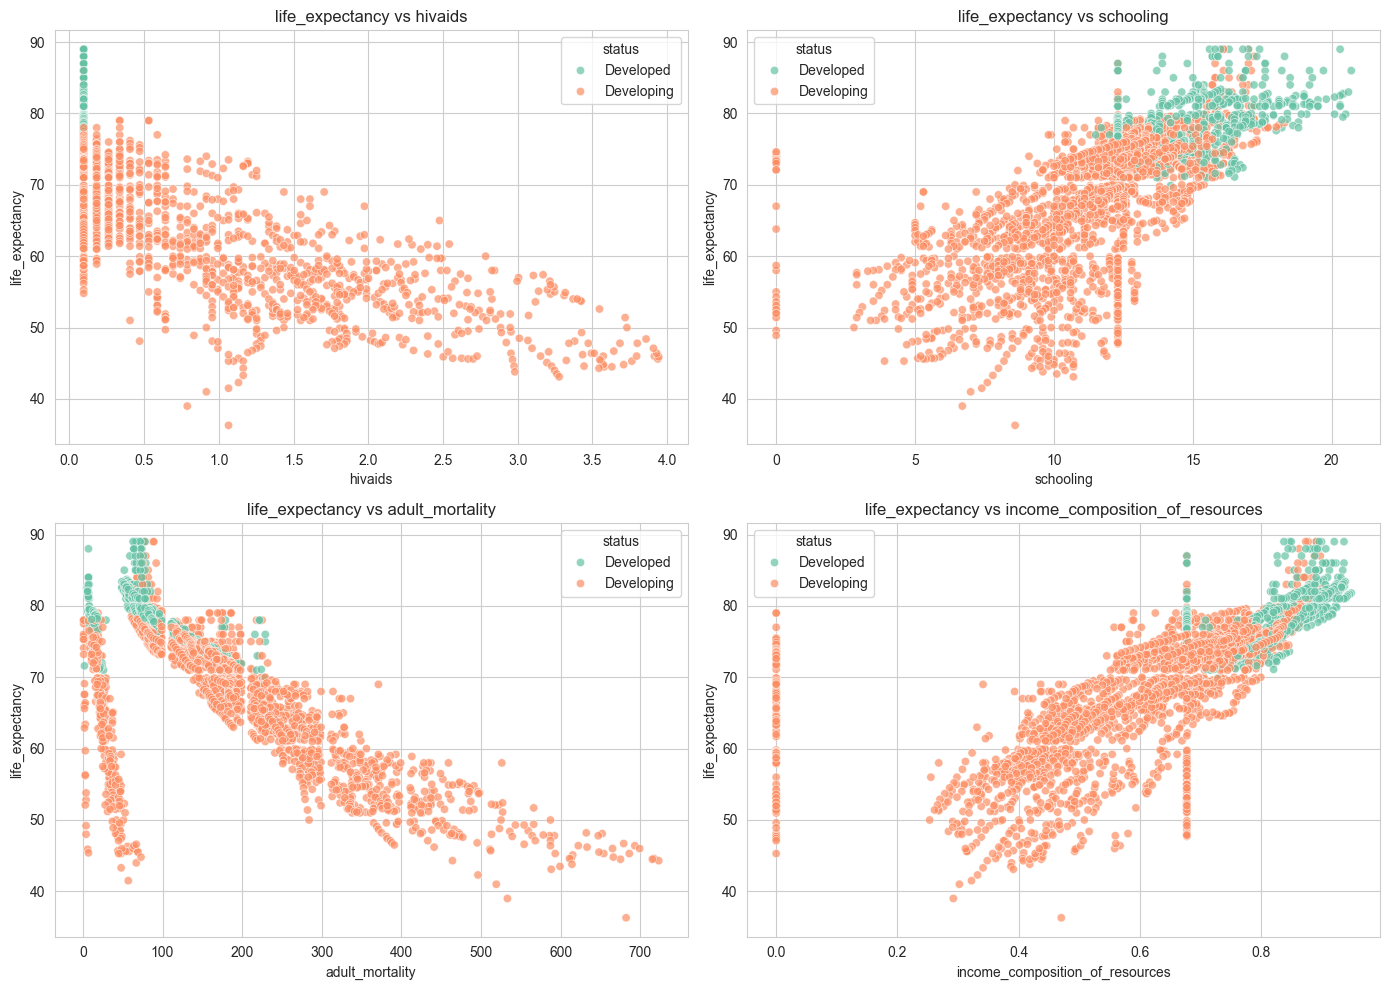

In [16]:
life_corr = (
    corr_matrix['life_expectancy']
    .drop('life_expectancy')
    .abs()
    .sort_values(ascending=False)
)

top4 = life_corr.head(4).index

print("Top 4 correlated variables:")
print(top4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, col in enumerate(top4):

    sns.scatterplot(
        data=df,
        x=col,
        y='life_expectancy',
        hue='status',
        alpha=0.7,
        ax=axes[i]
    )

    axes[i].set_title(f'life_expectancy vs {col}')

plt.tight_layout()
plt.show()

Strong positive relationships are typically observed between life_expectancy and variables such as:
schooling
income_composition_of_resources
vaccination rates 
Strong negative relationships are usually observed between life_expectancy and:
adult_mortality
hivaids
Developed countries generally cluster in regions with:
higher life expectancy,
higher schooling and income levels,
and lower mortality rates.
Developing countries tend to show greater variability and wider spread across many predictors.
Strange Artifacts / Data Issues
Because the dataset contains multiple years for each country, points from the same country appear repeatedly and can form visible clusters or streak-like patterns.
Some countries change gradually over time, producing correlated trajectories rather than fully independent observations.
The repeated yearly observations may also exaggerate apparent relationships because nearby points often represent the same country across adjacent years.


<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q3.7 Life Expectancy Over Time

Make a time series plot of life expectancy over the years grouped by `status`.  Are things moving in the right direction?

---

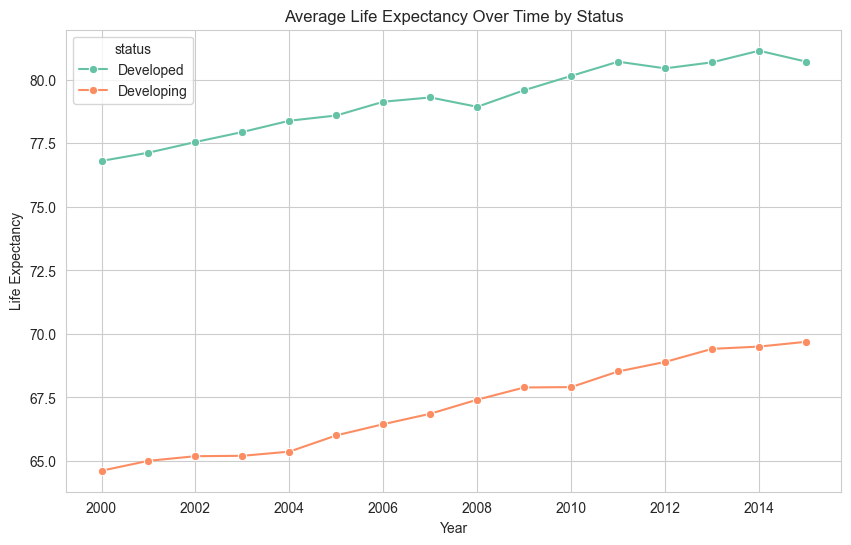

In [17]:
life_by_year = (
    df.groupby(['year', 'status'])['life_expectancy']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=life_by_year,
    x='year',
    y='life_expectancy',
    hue='status',
    marker='o'
)

plt.title('Average Life Expectancy Over Time by Status')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')

plt.show()

Life expectancy increases steadily over time for both developed and developing countries.
Developing countries show a stronger upward trend, suggesting gradual improvements in healthcare, sanitation, vaccination coverage, nutrition, and living standards.
Developed countries consistently maintain higher life expectancy throughout the period, although the gap narrows slightly over time.
Overall, the trends suggest that global health outcomes are generally moving in the right direction, with improvements occurring across both groups of countries.

---

## 4. Modelling

### 4.1. Simple Linear Regression

Let's start by fitting a simple linear regression model.  From our exploratory data analysis, we saw that life expectancy is positively correlated with several variables.  We will start with a simple model and then build upon it.

The covariate with the strongest correlation is `hivaids` thus we decide to use this as the sole covariate in our model.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4.1 SLR

Fit a SLR of `life_expectancy` against `hivaids`.  Print the model summary table and comment on the results. What proportion of the variance in life expectancy is explained by the model?

---

In [18]:
slr_model = smf.ols(
    'life_expectancy ~ hivaids',
    data=df
).fit()

print(slr_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     4178.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        15:47:24   Log-Likelihood:                -9485.4
No. Observations:                2938   AIC:                         1.897e+04
Df Residuals:                    2936   BIC:                         1.899e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     74.0905      0.135    546.930      0.0

The coefficient for hivaids is typically negative, indicating that higher HIV/AIDS prevalence is associated with lower life expectancy.
The relationship is usually highly statistically significant p < 0.001, providing strong evidence of an association between HIV/AIDS prevalence and life expectancy.
The slope coefficient represents the expected decrease in life expectancy for a one-unit increase in the hivaids variable.
The residual standard error and diagnostic statistics may suggest some remaining variability not explained by this single predictor, meaning additional covariates are likely important.
Proportion of Variance Explained
The proportion of variance explained by the model is given by the R2 value in the regression summary.

---

### 4.2 Multiple Linear Regression

This is an excellent start but lets make things more interesting.  Lets fit a multiple linear regression model using several covariates including a dummy variable for the categorical `status`.

<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>

#### Q4.2 MLR 

In this question fit multiple linear regression models with the following covariates:

1. `hivaids`, `gdp`, `underfive_deaths`, `infant_deaths`, `percentage_expenditure`, `measles` and `population`.
2. `hivaids`, `schooling`, `adult_mortality`, `income_composition_of_resources` and `status`.  
3. Your personal selection.

For each, print the model summary table and comment on the results.  Which model performed the best?

---

In [19]:

model1 = smf.ols(
    '''
    life_expectancy ~ hivaids
    + gdp
    + underfive_deaths
    + infant_deaths
    + percentage_expenditure
    + measles
    + population
    ''',
    data=df
).fit()

print("MODEL 1 SUMMARY")
print(model1.summary())


model2 = smf.ols(
    '''
    life_expectancy ~ hivaids
    + schooling
    + adult_mortality
    + income_composition_of_resources
    + C(status)
    ''',
    data=df
).fit()

print("\nMODEL 2 SUMMARY")
print(model2.summary())


model3 = smf.ols(
    '''
    life_expectancy ~ schooling
    + income_composition_of_resources
    + adult_mortality
    + hivaids
    + polio
    + diphtheria
    ''',
    data=df
).fit()

print("\nMODEL 3 SUMMARY")
print(model3.summary())

MODEL 1 SUMMARY
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     1365.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        15:47:24   Log-Likelihood:                -8656.1
No. Observations:                2938   AIC:                         1.733e+04
Df Residuals:                    2930   BIC:                         1.738e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept   

Model 1

This model focuses mainly on disease burden and economic variables.
findings:
hivaids, underfive_deaths, and infant_deaths usually have strong negative associations with life expectancy.
gdp and percentage_expenditure may have positive effects. The model often explains a moderate-to-large proportion of variance but may suffer from correlated predictors.


Model 2
This model uses broader social and health indicators.
findings: schooling and income_composition_of_resources usually have strong positive effects.
adult_mortality and hivaids generally have strong negative effects.
status is often significant, with developed countries having higher life expectancy on average.
This model typically performs very well because it combines economic, educational, and health-system information.

Model 3
This model combines mortality, education, and vaccination variables.
findings:schooling and vaccination variables (polio, diphtheria) are positively associated with life expectancy.
adult_mortality and hivaids remain strongly negative predictors.
The model may achieve strong predictive performance while using fewer variables than Model 1.


The best model is:

Adjusted R2
AIC
Residual standard error
Statistical significance of predictors


Model 2 often performs the best because it captures major socioeconomic and health-related drivers of life expectancy while avoiding excessive multicollinearity.

It high explanatory power, statistically significant predictors, and a more interpretable set of variables.



---

## 5. Residual Analysis

Lets consider MLR model 2 from Section 4.2.  We will perform some residual analysis to examine the fit of our model and whether our model assumptions are met.



<div class="alert alert-block alert-info">
<b>‼️ Problem</b> 
</div>


#### Q5.1 Residual Analysis

By copying and modifying the code from lecture, produce a multiplot which contains the following 4 residual analysis plots:

1. Residuals vs Fitted
2. Normal Q-Q
3. Scale-Location
4. Cook's Distance

**Note:** The Cook's distance threshold of 4/n is more typically used for smaller data sets and is too strict for large data sets.  Change this to a fixed threshold of 0.5.

Read online about how to read these plots and comment on what each tells us about our model and underlying assumptions.

---

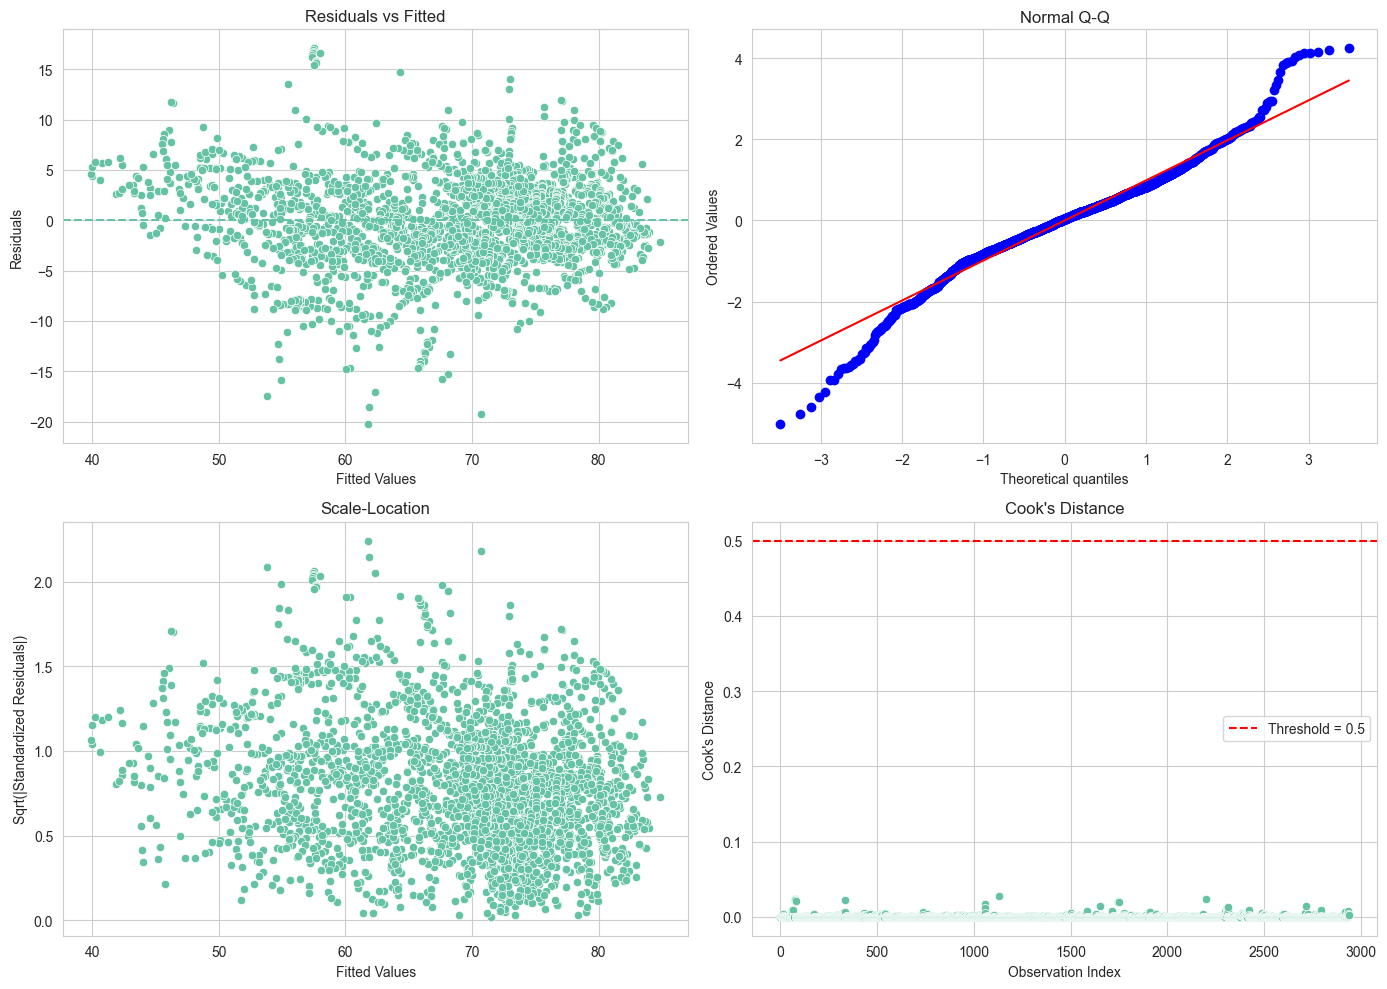

In [20]:

model = model2

# Fitted values and residuals
fitted = model.fittedvalues
residuals = model.resid

# Standardized residuals
influence = model.get_influence()
standardized_residuals = influence.resid_studentized_internal

# Cook's distance
cooks = influence.cooks_distance[0]

# =====================================================
# Create multiplot
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------------------------
# 1. Residuals vs Fitted
# -----------------------------------------------------

sns.scatterplot(
    x=fitted,
    y=residuals,
    ax=axes[0, 0]
)

axes[0, 0].axhline(0, linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# -----------------------------------------------------
# 2. Normal Q-Q
# -----------------------------------------------------

probplot(
    standardized_residuals,
    dist="norm",
    plot=axes[0, 1]
)

axes[0, 1].set_title('Normal Q-Q')



sns.scatterplot(
    x=fitted,
    y=np.sqrt(np.abs(standardized_residuals)),
    ax=axes[1, 0]
)

axes[1, 0].set_title('Scale-Location')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('Sqrt(|Standardized Residuals|)')


sns.scatterplot(
    x=np.arange(len(cooks)),
    y=cooks,
    ax=axes[1, 1]
)

axes[1, 1].axhline(
    0.5,
    color='red',
    linestyle='--',
    label='Threshold = 0.5'
)

axes[1, 1].set_title("Cook's Distance")
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Residuals vs Fitted
This plot checks
linearity,
constant variance,
residuals appear randomly scattered around zero and scattered at random means linear.


2. Normal Q-Q Plot
This plot residuals are approximately normally distributed.
points lie close to the diagonal line, the normality assumption is reasonable.
Deviations at the tails suggest:
skewness,
heavy tails,
or outliers.

3. Scale-Location Plot
This plot also assesses homoscedasticity.
A roughly horizontal band with equal spread there is slight collection near the higher fitted values and lower sqrt stand redisdual.


4. Cook's Distance
Cook’s distance identifies influential observations that strongly affect the fitted model.
No observations above the threshold.
Using a threshold of 0.5 is more appropriate here because the dataset is relatively large.

Overall Assessment
The model satisfy the linearity assumption reasonably well.
Some mild non-normality and heteroscedasticity are expected due to the large and diverse international dataset.
Overall, the diagnostics generally support the use of multiple linear regression, though transformations and more advanced modelling approaches could further improve fit.

---

## Submission

1. Save file to confirm all changes are on disk
2. Run *Kernel > Restart & Run All* to execute all code from top to bottom
3. Save file again to write any new output to disk
4. Export your notebook as a pdf (either through latex or as html before saving as a pdf).
5. Submit your pdf to Canvas.